In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import json
import sys
sys.path.append("..")
from src.setting import GetInfo, PROJECT_PATH

from sklearn.decomposition import PCA
from scipy.linalg import eigh

In [3]:
ieeg_datapath = 'ieeg_shortWOBS_fs400'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

color_map_ieeg = plt.cm.Purples(np.linspace(0.3, 0.9, 5))
color_map_meg = plt.cm.Oranges(np.linspace(0.3, 0.9, 5))

frequencies_common = np.geomspace(0.5,100,20)
ratio = frequencies_common[1] / frequencies_common[0]
n_ieeg = int(np.floor(np.log(180 / 0.5) / np.log(ratio))) + 1
frequencies = 0.5 * ratio ** np.arange(n_ieeg)
frequencies = frequencies[frequencies <= 180]

meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(np.where(abs(coord) >100, coord/1000, coord)) >100, coord/1000, coord)/100

MEG Subject number :  32
iEEG Subject number :  30


Text(0, 0.5, 'Freq')

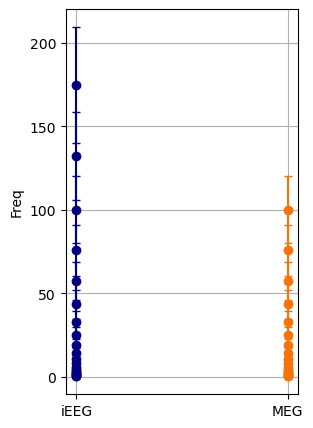

In [4]:
plt.figure(figsize=(3, 5))
bandwidth_ieeg = np.maximum(0.5, 0.20 * frequencies)
bandwidth_meg = np.maximum(0.5, 0.20 * frequencies_common)
plt.errorbar(['iEEG'] * len(frequencies),frequencies,yerr=bandwidth_ieeg,fmt='o',capsize=3, c='navy')
plt.errorbar(['MEG'] * len(frequencies_common),frequencies_common,yerr=bandwidth_meg,fmt='o',capsize=3, c='#F97306')
plt.grid(True)
plt.ylabel('Freq')

In [5]:
# Get the expl var from cluster computation 
out_path='out/freq' 
nb_compo = 1026

with open(out_path + f'/match_expl_var_r_{nb_compo}.p', "rb") as f:
    expl_var_r_meg = pickle.load(f)

with open(out_path + f'/match_expl_var_{nb_compo}.p', "rb") as f:
    expl_var_meg = pickle.load(f)

with open(out_path + f'/ieeg_expl_var_r_{nb_compo}.p', "rb") as f:
    expl_var_r_ieeg = pickle.load(f)

with open(out_path + f'/ieeg_expl_var_{nb_compo}.p', "rb") as f:
    expl_var_ieeg = pickle.load(f)

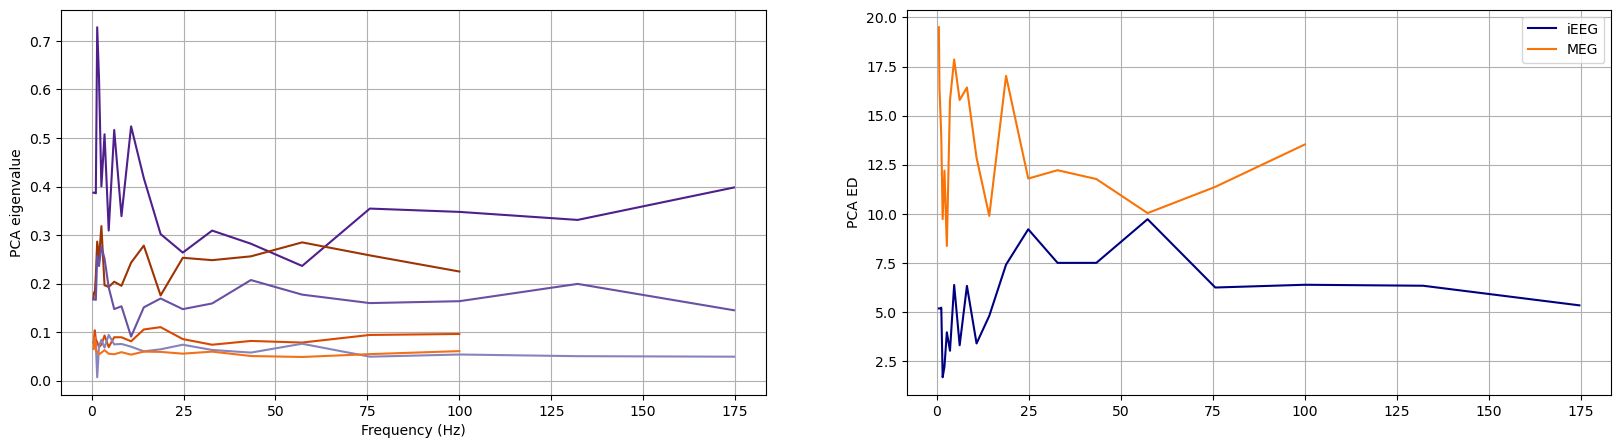

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

for x in range(3) :
    ax[0].plot(frequencies,expl_var_r_ieeg[:, x], c=color_map_ieeg[4-x])
    ax[0].plot(frequencies_common,expl_var_r_meg[:, x],  c=color_map_meg[4-x])

ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("PCA eigenvalue")
ax[0].grid(True)

ax[1].set_ylabel("PCA ED")
ED = np.sum(expl_var_ieeg, axis=1)**2/np.sum(expl_var_ieeg**2,  axis=1)
ax[1].plot(frequencies, ED, label='iEEG', c='navy')
ax[1].grid(True)

ED = np.sum(expl_var_meg, axis=1)**2/np.sum(expl_var_meg**2,  axis=1)
ax[1].plot(frequencies_common, ED, label='MEG', c='#F97306')
ax[1].legend()
